# Chapter 29 — Motion-Aware Global Assignment

This self-contained notebook rebuilds the detector and compares greedy linking, spatial Hungarian assignment, and motion-aware Hungarian assignment.

In [1]:
!pip install -q zarr

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from skimage.feature import blob_log
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 75.3 MB/s eta 0:00:00


In [2]:
base = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
sample_id = "44b6_12dfb391"
zarr_path = base / "train" / f"{sample_id}.zarr"
geff_path = base / "train" / f"{sample_id}.geff"

if not base.exists():
    raise FileNotFoundError("Attach the Biohub competition data with Add Input.")

image = zarr.open(zarr_path, mode="r")["0"]
geff = zarr.open(geff_path, mode="r")

nodes_df = pd.DataFrame({
    "node_id": geff["nodes/ids"][:],
    "t": geff["nodes/props/t/values"][:],
    "z": geff["nodes/props/z/values"][:],
    "y": geff["nodes/props/y/values"][:],
    "x": geff["nodes/props/x/values"][:],
})

print("Image shape:", image.shape)
print("GT nodes:", len(nodes_df))
display(nodes_df.head())


Image shape: (100, 64, 256, 256)
GT nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


In [3]:
def first_existing_array(group, paths):
    for path in paths:
        try:
            return np.asarray(group[path][:]), path
        except Exception:
            pass
    return None, None


def load_geff_edges(group):
    source_paths = [
        "edges/source", "edges/sources", "edges/source_ids",
        "edges/props/source/values", "edges/props/source_id/values",
    ]
    target_paths = [
        "edges/target", "edges/targets", "edges/target_ids",
        "edges/props/target/values", "edges/props/target_id/values",
    ]

    sources, source_path = first_existing_array(group, source_paths)
    targets, target_path = first_existing_array(group, target_paths)

    if sources is not None and targets is not None:
        print("Source path:", source_path)
        print("Target path:", target_path)
        return pd.DataFrame({"source": sources, "target": targets})

    for path in ["edges/ids", "edges/index", "edges/indices", "edges/endpoints"]:
        try:
            arr = np.asarray(group[path][:])
            if arr.ndim == 2 and arr.shape[1] == 2:
                return pd.DataFrame(arr, columns=["source", "target"])
            if arr.ndim == 2 and arr.shape[0] == 2:
                return pd.DataFrame({"source": arr[0], "target": arr[1]})
        except Exception:
            pass

    raise KeyError("Could not identify GEFF edge arrays.")


edges_df = load_geff_edges(geff)
source_nodes = nodes_df.rename(columns={
    "node_id": "source", "t": "source_t", "z": "source_z",
    "y": "source_y", "x": "source_x",
})
target_nodes = nodes_df.rename(columns={
    "node_id": "target", "t": "target_t", "z": "target_z",
    "y": "target_y", "x": "target_x",
})

edge_detail_df = (
    edges_df.merge(source_nodes, on="source", how="left")
            .merge(target_nodes, on="target", how="left")
)
edge_detail_df["time_gap"] = edge_detail_df["target_t"] - edge_detail_df["source_t"]
consecutive_edges_df = edge_detail_df[edge_detail_df["time_gap"] == 1].copy()

print("GT edges:", len(edges_df))
print("Consecutive GT edges:", len(consecutive_edges_df))


GT edges: 773
Consecutive GT edges: 773


In [4]:
def pairwise_distances_3d(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)), dtype=float)
    return cdist(a, b)


def extract_patch_3d(volume, z, y, x, rz=2, ryx=4):
    z0, z1 = max(0, z-rz), min(volume.shape[0], z+rz+1)
    y0, y1 = max(0, y-ryx), min(volume.shape[1], y+ryx+1)
    x0, x1 = max(0, x-ryx), min(volume.shape[2], x+ryx+1)
    return volume[z0:z1, y0:y1, x0:x1], (z0, z1, y0, y1, x0, x1)


In [5]:
def compute_2d_candidate_features(frame_3d, candidate_df, patch_radius=4):
    rows = []
    for _, r in candidate_df.iterrows():
        z, y, x = int(r.z), int(r.y), int(r.x)
        sigma = float(r.sigma)
        y0, y1 = max(0, y-patch_radius), min(frame_3d.shape[1], y+patch_radius+1)
        x0, x1 = max(0, x-patch_radius), min(frame_3d.shape[2], x+patch_radius+1)
        patch = frame_3d[z, y0:y1, x0:x1]
        if patch.size == 0:
            continue

        center_intensity = float(frame_3d[z, y, x])
        patch_mean, patch_max = float(patch.mean()), float(patch.max())
        patch_std = float(patch.std())
        local_contrast = patch_max - patch_mean

        py, px = np.unravel_index(np.argmax(patch), patch.shape)
        cy, cx = (patch.shape[0]-1)/2, (patch.shape[1]-1)/2
        center_to_patch_max_dist = float(np.hypot(py-cy, px-cx))

        yy, xx = np.indices(patch.shape)
        mass = patch.astype(float)
        if mass.sum() > 0:
            com_y = (yy*mass).sum()/mass.sum()
            com_x = (xx*mass).sum()/mass.sum()
            patch_com_offset = float(np.hypot(com_y-cy, com_x-cx))
        else:
            patch_com_offset = 0.0

        is_near_border = int(
            z <= 1 or z >= frame_3d.shape[0]-2 or
            y <= patch_radius or y >= frame_3d.shape[1]-patch_radius-1 or
            x <= patch_radius or x >= frame_3d.shape[2]-patch_radius-1
        )

        rows.append({
            "z": z, "y": y, "x": x, "sigma": sigma,
            "center_intensity": center_intensity,
            "patch_mean": patch_mean, "patch_max": patch_max,
            "patch_std": patch_std, "local_contrast": local_contrast,
            "center_to_patch_max_dist": center_to_patch_max_dist,
            "patch_com_offset": patch_com_offset,
            "is_near_border": is_near_border,
        })
    return pd.DataFrame(rows)


In [6]:
def compute_3d_candidate_features(frame_3d, candidate_df, rz=2, ryx=4):
    rows = []
    for _, r in candidate_df.iterrows():
        z, y, x = int(r.z), int(r.y), int(r.x)
        patch, bounds = extract_patch_3d(frame_3d, z, y, x, rz, ryx)
        z0, z1, y0, y1, x0, x1 = bounds
        if patch.size == 0:
            continue

        lz, ly, lx = z-z0, y-y0, x-x0
        center_voxel = float(patch[lz, ly, lx])
        vol_mean, vol_std, vol_max = float(patch.mean()), float(patch.std()), float(patch.max())
        z_line = patch[:, ly, lx]
        z_line_mean, z_line_std, z_line_max = float(z_line.mean()), float(z_line.std()), float(z_line.max())
        center_over_vol_mean = center_voxel/(vol_mean+1e-6)
        center_minus_vol_mean = center_voxel-vol_mean

        neighbors = []
        if lz-1 >= 0:
            neighbors.append(patch[lz-1])
        if lz+1 < patch.shape[0]:
            neighbors.append(patch[lz+1])
        neighbor_mean = float(np.mean([s.mean() for s in neighbors])) if neighbors else vol_mean
        center_slice_minus_neighbor_mean = float(patch[lz].mean()-neighbor_mean)
        slice_mean_std = float(np.std([s.mean() for s in patch]))

        peak_z, _, _ = np.unravel_index(np.argmax(patch), patch.shape)
        z_peak_offset = int(abs(peak_z-lz))

        zz, yy, xx = np.indices(patch.shape)
        mass = patch.astype(float)
        if mass.sum() > 0:
            com_z = (zz*mass).sum()/mass.sum()
            com_y = (yy*mass).sum()/mass.sum()
            com_x = (xx*mass).sum()/mass.sum()
            mass_center_offset_3d = float(np.sqrt((com_z-lz)**2 + (com_y-ly)**2 + (com_x-lx)**2))
        else:
            mass_center_offset_3d = 0.0

        rows.append({
            "z": z, "y": y, "x": x,
            "center_voxel": center_voxel,
            "vol_mean": vol_mean, "vol_std": vol_std, "vol_max": vol_max,
            "z_line_mean": z_line_mean, "z_line_std": z_line_std, "z_line_max": z_line_max,
            "center_over_vol_mean": center_over_vol_mean,
            "center_minus_vol_mean": center_minus_vol_mean,
            "center_slice_minus_neighbor_mean": center_slice_minus_neighbor_mean,
            "slice_mean_std": slice_mean_std,
            "z_peak_offset": z_peak_offset,
            "mass_center_offset_3d": mass_center_offset_3d,
            "peak_to_mean_ratio": vol_max/(vol_mean+1e-6),
            "bright_fraction": float((patch > vol_mean).mean()),
        })
    return pd.DataFrame(rows)


In [7]:
def detect_slice_wise_log(frame_3d, log_kwargs):
    rows = []
    for z in range(frame_3d.shape[0]):
        sl = frame_3d[z].astype(np.float32)
        mn, mx = float(sl.min()), float(sl.max())
        if mx <= mn:
            continue
        sl = (sl-mn)/(mx-mn)

        blobs = blob_log(
            sl,
            min_sigma=log_kwargs.get("min_sigma", 2.5),
            max_sigma=log_kwargs.get("max_sigma", 3.5),
            num_sigma=log_kwargs.get("num_sigma", 3),
            threshold=log_kwargs.get("threshold", 0.15),
        )

        for y, x, sigma in blobs:
            y = int(np.clip(round(y), 0, frame_3d.shape[1]-1))
            x = int(np.clip(round(x), 0, frame_3d.shape[2]-1))
            rows.append({
                "z": z, "y": y, "x": x, "sigma": float(sigma),
                "nms_score": float(frame_3d[z, y, x]),
            })

    if not rows:
        return pd.DataFrame(columns=["z","y","x","sigma","nms_score"])

    return pd.DataFrame(rows).drop_duplicates(["z","y","x"]).reset_index(drop=True)


def greedy_3d_nms(candidate_df, nms_radius=3.0):
    if len(candidate_df) == 0:
        return candidate_df.copy()

    work = candidate_df.sort_values("nms_score", ascending=False).reset_index(drop=True)
    kept = []

    while len(work):
        row = work.iloc[0].copy()
        kept.append(row)
        p = np.array([row.z, row.y, row.x], dtype=float)
        pts = work[["z","y","x"]].to_numpy(dtype=float)
        d = np.sqrt(((pts-p)**2).sum(axis=1))
        work = work[d > nms_radius].reset_index(drop=True)

    return pd.DataFrame(kept).reset_index(drop=True)


def build_candidate_feature_table(image, t, log_kwargs, nms_radius=3.0):
    frame = np.asarray(image[t])
    raw = detect_slice_wise_log(frame, log_kwargs)
    nms = greedy_3d_nms(raw, nms_radius)

    if len(nms) == 0:
        return pd.DataFrame(), frame, raw

    f2 = compute_2d_candidate_features(frame, nms[["z","y","x","sigma"]].copy())
    f3 = compute_3d_candidate_features(frame, nms[["z","y","x"]].copy())

    df = nms.merge(f2, on=["z","y","x"], how="left", suffixes=("","_2d"))
    df = df.merge(f3, on=["z","y","x"], how="left", suffixes=("","_3d"))
    df = df.drop(columns=["nms_score"], errors="ignore")
    df["t"] = t
    return df, frame, raw


In [8]:
train_timesteps = [0, 8, 20, 40]
nms_radius = 3.0
distance_clip = 20.0

log_kwargs = {
    "min_sigma": 2.5,
    "max_sigma": 3.5,
    "num_sigma": 3,
    "threshold": 0.15,
}

feature_cols = [
    "sigma","center_intensity","patch_mean","patch_max","patch_std",
    "local_contrast","center_to_patch_max_dist","patch_com_offset",
    "is_near_border","center_voxel","vol_mean","vol_std","vol_max",
    "z_line_mean","z_line_std","z_line_max","center_over_vol_mean",
    "center_minus_vol_mean","center_slice_minus_neighbor_mean",
    "slice_mean_std","z_peak_offset","mass_center_offset_3d",
    "peak_to_mean_ratio","bright_fraction",
]


In [9]:
train_tables = []

for t in train_timesteps:
    cand, frame, raw = build_candidate_feature_table(image, t, log_kwargs, nms_radius)
    if len(cand) == 0:
        continue

    gt = nodes_df[nodes_df["t"] == t]
    gt_pts = gt[["z","y","x"]].to_numpy(dtype=float)
    pred_pts = cand[["z","y","x"]].to_numpy(dtype=float)

    cand["nearest_gt_dist"] = (
        pairwise_distances_3d(gt_pts, pred_pts).min(axis=0)
        if len(gt_pts) else np.inf
    )
    cand["target_dist"] = cand["nearest_gt_dist"].clip(0, distance_clip)
    train_tables.append(cand)
    print(f"t={t}: raw={len(raw)}, nms={len(cand)}")

train_df = pd.concat(train_tables, ignore_index=True)

distance_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)

distance_model.fit(
    train_df[feature_cols].fillna(0.0),
    train_df["target_dist"],
)

print("Training rows:", len(train_df))


t=0: raw=1541, nms=670
t=8: raw=1478, nms=661
t=20: raw=1653, nms=695
t=40: raw=1596, nms=688
Training rows: 2714


In [10]:
def run_final_candidate_detector(image, t, model, feature_cols, log_kwargs, nms_radius=3.0, top_k=200):
    cand, frame, raw = build_candidate_feature_table(image, t, log_kwargs, nms_radius)

    if len(cand) == 0:
        empty = pd.DataFrame(columns=[
            "t","node_id","rank_position","z","y","x","sigma","pred_dist"
        ])
        return {
            "raw_candidates": raw,
            "ranked_candidates": empty,
            "selected_candidates": empty.copy(),
            "frame_3d": frame,
        }

    ranked = cand.copy()
    ranked["pred_dist"] = model.predict(ranked[feature_cols].fillna(0.0))
    ranked = ranked.sort_values("pred_dist").reset_index(drop=True)
    ranked["rank_position"] = np.arange(1, len(ranked)+1)
    ranked["node_id"] = [f"pred_t{t}_{i}" for i in range(len(ranked))]

    return {
        "raw_candidates": raw,
        "ranked_candidates": ranked,
        "selected_candidates": ranked.head(min(top_k, len(ranked))).copy(),
        "frame_3d": frame,
    }


In [11]:
start_t = 0
end_t = 20
top_k = 200

tables = []
for t in range(start_t, end_t + 1):
    out = run_final_candidate_detector(
        image, t, distance_model, feature_cols,
        log_kwargs, nms_radius, top_k
    )
    tables.append(out["selected_candidates"])
    print(
        f"t={t}: raw={len(out['raw_candidates'])}, "
        f"ranked={len(out['ranked_candidates'])}, "
        f"selected={len(out['selected_candidates'])}"
    )

detections_df = pd.concat(tables, ignore_index=True)
print("Total detections:", len(detections_df))
display(detections_df[["t","node_id","rank_position","z","y","x","pred_dist"]].head())


t=0: raw=1541, ranked=670, selected=200
t=1: raw=1530, ranked=651, selected=200
t=2: raw=1687, ranked=706, selected=200
t=3: raw=1540, ranked=656, selected=200
t=4: raw=1555, ranked=658, selected=200
t=5: raw=1461, ranked=606, selected=200
t=6: raw=1355, ranked=585, selected=200
t=7: raw=1365, ranked=598, selected=200
t=8: raw=1478, ranked=661, selected=200
t=9: raw=1619, ranked=679, selected=200
t=10: raw=1639, ranked=687, selected=200
t=11: raw=1655, ranked=702, selected=200
t=12: raw=1556, ranked=662, selected=200
t=13: raw=1519, ranked=664, selected=200
t=14: raw=1609, ranked=693, selected=200
t=15: raw=1641, ranked=711, selected=200
t=16: raw=1651, ranked=697, selected=200
t=17: raw=1674, ranked=716, selected=200
t=18: raw=1675, ranked=730, selected=200
t=19: raw=1667, ranked=716, selected=200
t=20: raw=1653, ranked=695, selected=200
Total detections: 4200


,t,node_id,rank_position,z,y,x,pred_dist
0,0,pred_t0_0,1,24.0,189.0,56.0,15.303363
1,0,pred_t0_1,2,27.0,212.0,110.0,15.671573
2,0,pred_t0_2,3,7.0,241.0,51.0,15.697220
3,0,pred_t0_3,4,44.0,127.0,127.0,15.798581
4,0,pred_t0_4,5,22.0,208.0,55.0,16.286263


In [12]:
def greedy_one_to_one_links(source_df, target_df, max_movement=10.0):
    if len(source_df) == 0 or len(target_df) == 0:
        return pd.DataFrame(columns=["source","target","distance"])

    s = source_df[["z","y","x"]].to_numpy(dtype=float)
    t = target_df[["z","y","x"]].to_numpy(dtype=float)
    dist = cdist(s, t)

    si, ti = np.indices(dist.shape)
    pairs = pd.DataFrame({
        "source_index": si.ravel(),
        "target_index": ti.ravel(),
        "distance": dist.ravel(),
    })
    pairs = pairs[pairs["distance"] <= max_movement].sort_values("distance")

    used_s, used_t, rows = set(), set(), []

    for _, r in pairs.iterrows():
        a, b = int(r.source_index), int(r.target_index)
        if a in used_s or b in used_t:
            continue
        used_s.add(a)
        used_t.add(b)
        rows.append({
            "source": source_df.iloc[a]["node_id"],
            "target": target_df.iloc[b]["node_id"],
            "distance": float(r.distance),
        })

    return pd.DataFrame(rows)


def hungarian_links(source_df, target_df, source_positions=None, max_movement=10.0, invalid_cost=1e6):
    if len(source_df) == 0 or len(target_df) == 0:
        return pd.DataFrame(columns=["source","target","distance","assignment_cost"])

    source_points = (
        source_df[["z","y","x"]].to_numpy(dtype=float)
        if source_positions is None
        else np.asarray(source_positions, dtype=float)
    )
    target_points = target_df[["z","y","x"]].to_numpy(dtype=float)

    dist = cdist(source_points, target_points)
    cost = dist.copy()
    cost[dist > max_movement] = invalid_cost

    row_ind, col_ind = linear_sum_assignment(cost)
    rows = []

    for a, b in zip(row_ind, col_ind):
        if cost[a, b] >= invalid_cost:
            continue
        rows.append({
            "source": source_df.iloc[a]["node_id"],
            "target": target_df.iloc[b]["node_id"],
            "distance": float(dist[a, b]),
            "assignment_cost": float(cost[a, b]),
        })

    return pd.DataFrame(rows)


In [13]:
def build_tracks_from_links(detections_df, links_df):
    detections = detections_df.sort_values(["t","rank_position"]).copy().reset_index(drop=True)
    incoming = {r["target"]: r["source"] for _, r in links_df.iterrows()}

    track_id_by_node = {}
    next_track_id = 0

    for _, row in detections.iterrows():
        node_id = row["node_id"]
        if node_id in incoming and incoming[node_id] in track_id_by_node:
            track_id_by_node[node_id] = track_id_by_node[incoming[node_id]]
        else:
            track_id_by_node[node_id] = next_track_id
            next_track_id += 1

    tracks = detections.copy()
    tracks["track_id"] = tracks["node_id"].map(track_id_by_node)
    return tracks


def summarize_tracks(tracks_df, method_name):
    summary = tracks_df.groupby("track_id", as_index=False).agg(
        start_t=("t","min"),
        end_t=("t","max"),
        num_detections=("node_id","count"),
        mean_pred_dist=("pred_dist","mean"),
        mean_rank=("rank_position","mean"),
    )
    summary["duration"] = summary["end_t"] - summary["start_t"] + 1
    summary["method"] = method_name
    return summary


In [14]:
max_movement = 10.0

greedy_tables = []
hungarian_tables = []

for source_t in range(start_t, end_t):
    target_t = source_t + 1
    source_df = detections_df[detections_df["t"] == source_t].copy().reset_index(drop=True)
    target_df = detections_df[detections_df["t"] == target_t].copy().reset_index(drop=True)

    g = greedy_one_to_one_links(source_df, target_df, max_movement)
    g["source_t"] = source_t
    g["target_t"] = target_t
    greedy_tables.append(g)

    h = hungarian_links(source_df, target_df, max_movement=max_movement)
    h["source_t"] = source_t
    h["target_t"] = target_t
    hungarian_tables.append(h)

greedy_links_df = pd.concat(greedy_tables, ignore_index=True)
hungarian_links_df = pd.concat(hungarian_tables, ignore_index=True)

greedy_tracks_df = build_tracks_from_links(detections_df, greedy_links_df)
hungarian_tracks_df = build_tracks_from_links(detections_df, hungarian_links_df)

greedy_summary_df = summarize_tracks(greedy_tracks_df, "greedy")
hungarian_summary_df = summarize_tracks(hungarian_tracks_df, "hungarian_spatial")

print("Greedy links:", len(greedy_links_df))
print("Hungarian links:", len(hungarian_links_df))


Greedy links: 1923
Hungarian links: 1973


In [15]:
def build_motion_aware_tracks(detections_df, start_t, end_t, max_movement=10.0, velocity_weight=1.0):
    detections_by_t = {
        t: detections_df[detections_df["t"] == t].copy().reset_index(drop=True)
        for t in range(start_t, end_t + 1)
    }

    track_history = {}
    active_tracks = {}
    next_track_id = 0

    for _, row in detections_by_t[start_t].iterrows():
        track_history[next_track_id] = [{
            "t": int(row.t), "node_id": row.node_id,
            "z": float(row.z), "y": float(row.y), "x": float(row.x),
        }]
        active_tracks[next_track_id] = row.node_id
        next_track_id += 1

    link_rows = []

    for source_t in range(start_t, end_t):
        target_t = source_t + 1
        source_df = detections_by_t[source_t]
        target_df = detections_by_t[target_t]

        node_to_track = {node_id: tid for tid, node_id in active_tracks.items()}
        active_source_df = source_df[source_df["node_id"].isin(node_to_track)].copy().reset_index(drop=True)

        predicted_positions = []
        for _, source_row in active_source_df.iterrows():
            tid = node_to_track[source_row.node_id]
            history = track_history[tid]
            current = np.array([source_row.z, source_row.y, source_row.x], dtype=float)

            if len(history) >= 2:
                previous = np.array([history[-2]["z"], history[-2]["y"], history[-2]["x"]], dtype=float)
                predicted = current + velocity_weight * (current - previous)
            else:
                predicted = current

            predicted_positions.append(predicted)

        links_t = hungarian_links(
            active_source_df,
            target_df,
            source_positions=predicted_positions,
            max_movement=max_movement,
        )

        new_active = {}
        linked_targets = set()

        for _, link in links_t.iterrows():
            source_node, target_node = link.source, link.target
            tid = node_to_track[source_node]
            target_row = target_df[target_df["node_id"] == target_node].iloc[0]

            track_history[tid].append({
                "t": int(target_row.t), "node_id": target_node,
                "z": float(target_row.z), "y": float(target_row.y), "x": float(target_row.x),
            })
            new_active[tid] = target_node
            linked_targets.add(target_node)

            link_rows.append({
                "source": source_node,
                "target": target_node,
                "distance": float(link.distance),
                "assignment_cost": float(link.assignment_cost),
                "source_t": source_t,
                "target_t": target_t,
                "track_id": tid,
            })

        for _, target_row in target_df[~target_df["node_id"].isin(linked_targets)].iterrows():
            target_node = target_row.node_id
            track_history[next_track_id] = [{
                "t": int(target_row.t), "node_id": target_node,
                "z": float(target_row.z), "y": float(target_row.y), "x": float(target_row.x),
            }]
            new_active[next_track_id] = target_node
            next_track_id += 1

        active_tracks = new_active

    motion_links_df = pd.DataFrame(link_rows)
    node_to_track_id = {}
    for tid, history in track_history.items():
        for item in history:
            node_to_track_id[item["node_id"]] = tid

    motion_tracks_df = detections_df.copy()
    motion_tracks_df["track_id"] = motion_tracks_df["node_id"].map(node_to_track_id)
    return motion_tracks_df, motion_links_df


In [16]:
motion_tracks_df, motion_links_df = build_motion_aware_tracks(
    detections_df,
    start_t=start_t,
    end_t=end_t,
    max_movement=max_movement,
    velocity_weight=1.0,
)

motion_summary_df = summarize_tracks(motion_tracks_df, "hungarian_motion")

comparison_df = pd.DataFrame({
    "method": ["greedy", "hungarian_spatial", "hungarian_motion"],
    "num_links": [len(greedy_links_df), len(hungarian_links_df), len(motion_links_df)],
    "num_tracks": [
        greedy_tracks_df["track_id"].nunique(),
        hungarian_tracks_df["track_id"].nunique(),
        motion_tracks_df["track_id"].nunique(),
    ],
    "mean_track_duration": [
        greedy_summary_df["duration"].mean(),
        hungarian_summary_df["duration"].mean(),
        motion_summary_df["duration"].mean(),
    ],
    "median_track_duration": [
        greedy_summary_df["duration"].median(),
        hungarian_summary_df["duration"].median(),
        motion_summary_df["duration"].median(),
    ],
    "max_track_duration": [
        greedy_summary_df["duration"].max(),
        hungarian_summary_df["duration"].max(),
        motion_summary_df["duration"].max(),
    ],
})

display(comparison_df)


,method,num_links,num_tracks,mean_track_duration,median_track_duration,max_track_duration
0,greedy,1923,2277,1.844532,1.0,13
1,hungarian_spatial,1973,2227,1.885945,1.0,13
2,hungarian_motion,1916,2284,1.838879,1.0,15


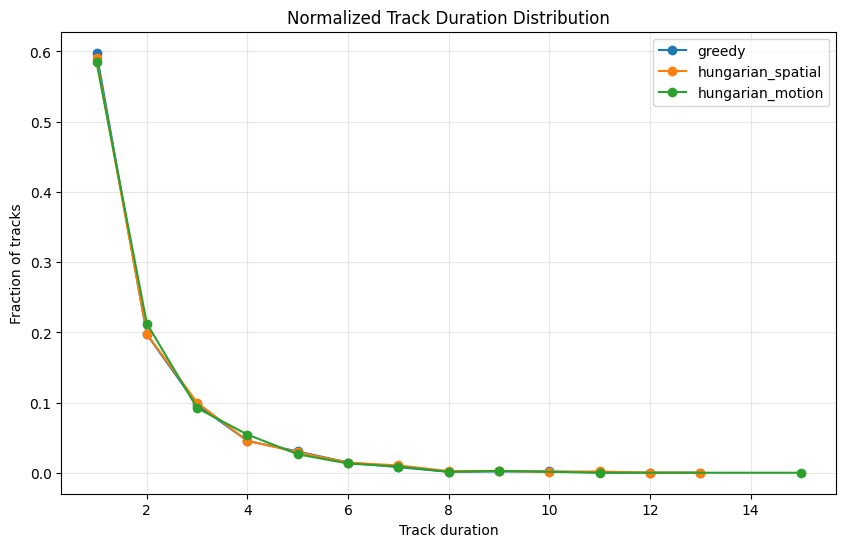

In [17]:
plt.figure(figsize=(10, 6))

for method_name, summary_df in [
    ("greedy", greedy_summary_df),
    ("hungarian_spatial", hungarian_summary_df),
    ("hungarian_motion", motion_summary_df),
]:
    values = summary_df["duration"].value_counts(normalize=True).sort_index()
    plt.plot(values.index, values.values, marker="o", label=method_name)

plt.title("Normalized Track Duration Distribution")
plt.xlabel("Track duration")
plt.ylabel("Fraction of tracks")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [18]:
def match_predicted_nodes_to_gt(predicted_df, gt_df, match_radius=6.0):
    rows = []

    for t in sorted(predicted_df["t"].unique()):
        pred_t = predicted_df[predicted_df["t"] == t].copy().reset_index(drop=True)
        gt_t = gt_df[gt_df["t"] == t].copy().reset_index(drop=True)

        if len(pred_t) == 0 or len(gt_t) == 0:
            continue

        dist = cdist(
            pred_t[["z","y","x"]].to_numpy(dtype=float),
            gt_t[["z","y","x"]].to_numpy(dtype=float),
        )

        pi, gi = np.indices(dist.shape)
        pairs = pd.DataFrame({
            "pred_index": pi.ravel(),
            "gt_index": gi.ravel(),
            "distance": dist.ravel(),
        })
        pairs = pairs[pairs["distance"] <= match_radius].sort_values("distance")

        used_p, used_g = set(), set()
        for _, r in pairs.iterrows():
            p, g = int(r.pred_index), int(r.gt_index)
            if p in used_p or g in used_g:
                continue
            used_p.add(p)
            used_g.add(g)
            rows.append({
                "t": t,
                "pred_node_id": pred_t.iloc[p]["node_id"],
                "gt_node_id": gt_t.iloc[g]["node_id"],
                "match_distance": float(r.distance),
            })

    return pd.DataFrame(rows)


node_matches_df = match_predicted_nodes_to_gt(detections_df, nodes_df, 6.0)
pred_to_gt = dict(zip(node_matches_df["pred_node_id"], node_matches_df["gt_node_id"]))

true_edges_range_df = consecutive_edges_df[
    (consecutive_edges_df["source_t"] >= start_t) &
    (consecutive_edges_df["target_t"] <= end_t)
].copy()
true_gt_pairs = set(map(tuple, true_edges_range_df[["source","target"]].to_numpy()))

print("Matched predicted nodes:", len(node_matches_df))
print("True GT links in range:", len(true_gt_pairs))


Matched predicted nodes: 87
True GT links in range: 195


In [19]:
def evaluate_predicted_links(links_df, method_name):
    evaluated = links_df.copy()
    evaluated["matched_source_gt"] = evaluated["source"].map(pred_to_gt)
    evaluated["matched_target_gt"] = evaluated["target"].map(pred_to_gt)
    evaluated["both_nodes_matched"] = (
        evaluated["matched_source_gt"].notna() &
        evaluated["matched_target_gt"].notna()
    )
    evaluated["link_correct"] = [
        (s, t) in true_gt_pairs if pd.notna(s) and pd.notna(t) else False
        for s, t in zip(evaluated["matched_source_gt"], evaluated["matched_target_gt"])
    ]

    return {
        "method": method_name,
        "predicted_links": len(evaluated),
        "both_nodes_matched": int(evaluated["both_nodes_matched"].sum()),
        "correct_links": int(evaluated["link_correct"].sum()),
        "precision_all": evaluated["link_correct"].mean() if len(evaluated) else np.nan,
        "precision_matched_only": (
            evaluated.loc[evaluated["both_nodes_matched"], "link_correct"].mean()
            if evaluated["both_nodes_matched"].any() else np.nan
        ),
    }


link_evaluation_df = pd.DataFrame([
    evaluate_predicted_links(greedy_links_df, "greedy"),
    evaluate_predicted_links(hungarian_links_df, "hungarian_spatial"),
    evaluate_predicted_links(motion_links_df, "hungarian_motion"),
])

display(link_evaluation_df)


,method,predicted_links,both_nodes_matched,correct_links,precision_all,precision_matched_only
0,greedy,1923,27,27,0.014041,1.0
1,hungarian_spatial,1973,25,25,0.012671,1.0
2,hungarian_motion,1916,24,24,0.012526,1.0


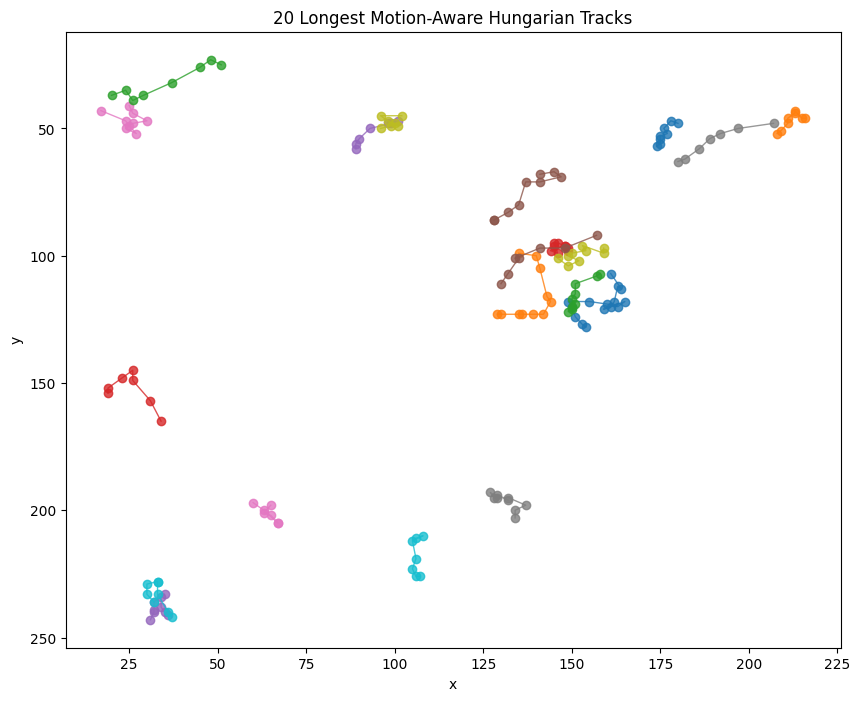

In [20]:
def plot_longest_tracks(tracks_df, summary_df, title, n_tracks=20):
    ids = summary_df.sort_values("duration", ascending=False).head(n_tracks)["track_id"].tolist()

    plt.figure(figsize=(10, 8))
    for track_id in ids:
        track = tracks_df[tracks_df["track_id"] == track_id].sort_values("t")
        plt.plot(track["x"], track["y"], marker="o", linewidth=1, alpha=0.8)

    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


plot_longest_tracks(
    motion_tracks_df,
    motion_summary_df,
    "20 Longest Motion-Aware Hungarian Tracks",
)


In [21]:
comparison_path = "/kaggle/working/chapter29_method_comparison.csv"
greedy_path = "/kaggle/working/chapter29_greedy_links.csv"
spatial_path = "/kaggle/working/chapter29_hungarian_spatial_links.csv"
motion_links_path = "/kaggle/working/chapter29_motion_hungarian_links.csv"
motion_tracks_path = "/kaggle/working/chapter29_motion_hungarian_tracks.csv"

comparison_df.to_csv(comparison_path, index=False)
greedy_links_df.to_csv(greedy_path, index=False)
hungarian_links_df.to_csv(spatial_path, index=False)
motion_links_df.to_csv(motion_links_path, index=False)
motion_tracks_df.to_csv(motion_tracks_path, index=False)

print("Saved:", comparison_path)
print("Saved:", greedy_path)
print("Saved:", spatial_path)
print("Saved:", motion_links_path)
print("Saved:", motion_tracks_path)


Saved: /kaggle/working/chapter29_method_comparison.csv
Saved: /kaggle/working/chapter29_greedy_links.csv
Saved: /kaggle/working/chapter29_hungarian_spatial_links.csv
Saved: /kaggle/working/chapter29_motion_hungarian_links.csv
Saved: /kaggle/working/chapter29_motion_hungarian_tracks.csv
